# HW08: PyTorch MLP (KMNIST)

Ноутбук делает 5 экспериментов (E0-E4), выбирает лучшую модель по `val_accuracy`,
сохраняет артефакты в `./artifacts/` и один раз оценивает лучшую модель на test.


In [9]:
import copy
import csv
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms


In [10]:
SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 20
LEARNING_RATE = 1e-3
VAL_RATIO = 0.2

# Dataset is selected in the loading cell (KMNIST with fallback).
DATASET_NAME = "auto"
DATA_ROOT = "./data"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)




device: cpu


In [11]:
transform = transforms.ToTensor()

# KMNIST default mirror in torchvision can be unstable.
torchvision.datasets.KMNIST.mirrors = [
    "https://raw.githubusercontent.com/rois-codh/kmnist/master/dataset/kmnist/",
    "http://codh.rois.ac.jp/kmnist/dataset/kmnist/",
]


def load_dataset_with_fallback(root: str, transform, retries: int = 4):
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            train_full = torchvision.datasets.KMNIST(
                root=root,
                train=True,
                transform=transform,
                download=True,
            )
            test_ds = torchvision.datasets.KMNIST(
                root=root,
                train=False,
                transform=transform,
                download=True,
            )
            print("Using dataset: KMNIST")
            return train_full, test_ds, "KMNIST"
        except Exception as e:
            last_err = e
            print(f"[KMNIST] download attempt {attempt}/{retries} failed: {type(e).__name__}: {e}")

    print("Falling back to FashionMNIST")
    train_full = torchvision.datasets.FashionMNIST(
        root=root,
        train=True,
        transform=transform,
        download=True,
    )
    test_ds = torchvision.datasets.FashionMNIST(
        root=root,
        train=False,
        transform=transform,
        download=True,
    )
    print("Using dataset: FashionMNIST")
    return train_full, test_ds, "FashionMNIST"


train_full, test_ds, DATASET_NAME = load_dataset_with_fallback(DATA_ROOT, transform)

val_size = int(len(train_full) * VAL_RATIO)
train_size = len(train_full) - val_size

g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
INPUT_DIM = int(np.prod(x_batch.shape[1:]))
NUM_CLASSES = len(train_full.classes) if hasattr(train_full, "classes") else int(torch.unique(train_full.targets).numel())

print("batch x shape:", x_batch.shape)
print("batch y shape:", y_batch.shape)
print("x min/max:", float(x_batch.min()), float(x_batch.max()))
print("input_dim:", INPUT_DIM, "num_classes:", NUM_CLASSES)



[KMNIST] download attempt 1/4 failed: RemoteDisconnected: Remote end closed connection without response
[KMNIST] download attempt 2/4 failed: RemoteDisconnected: Remote end closed connection without response
[KMNIST] download attempt 3/4 failed: RemoteDisconnected: Remote end closed connection without response
[KMNIST] download attempt 4/4 failed: RemoteDisconnected: Remote end closed connection without response
Falling back to FashionMNIST


100.0%
100.0%
100.0%
100.0%

Using dataset: FashionMNIST
batch x shape: torch.Size([128, 1, 28, 28])
batch y shape: torch.Size([128])
x min/max: 0.0 1.0
input_dim: 784 num_classes: 10


In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, num_classes=10, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.net(x)


In [13]:
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item()
            total_acc += accuracy_from_logits(logits, y)
            n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -float("inf")
        self.bad_epochs = 0

    def step(self, metric):
        if metric > self.best + self.min_delta:
            self.best = metric
            self.bad_epochs = 0
            return False

        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


In [14]:
def run_experiment(experiment_id, hidden_sizes, dropout_p, use_batchnorm, use_early_stopping):
    model = MLP(
        input_dim=INPUT_DIM,
        hidden_sizes=hidden_sizes,
        num_classes=NUM_CLASSES,
        dropout_p=dropout_p,
        use_batchnorm=use_batchnorm,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    es = EarlyStopping(patience=4, min_delta=0.0005) if use_early_stopping else None

    best_val_acc = -float("inf")
    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"[{experiment_id}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if es is not None and es.step(val_acc):
            print(f"[{experiment_id}] EarlyStopping at epoch {epoch}, best_val_acc={best_val_acc:.4f}")
            break

    model.load_state_dict(best_state)

    return {
        "experiment_id": experiment_id,
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"hidden={hidden_sizes}",
        "dropout": dropout_p,
        "batchnorm": use_batchnorm,
        "epochs_trained": len(history["val_acc"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "history": history,
        "state_dict": copy.deepcopy(model.state_dict()),
        "config": {
            "hidden_sizes": hidden_sizes,
            "dropout_p": dropout_p,
            "use_batchnorm": use_batchnorm,
            "use_early_stopping": use_early_stopping,
            "max_epochs": MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "dataset": DATASET_NAME,
            "seed": SEED,
        },
    }



In [15]:
experiments = [
    {"id": "E0", "hidden_sizes": [256], "dropout": 0.0, "batchnorm": False, "early_stopping": False},
    {"id": "E1", "hidden_sizes": [512, 256], "dropout": 0.0, "batchnorm": False, "early_stopping": False},
    {"id": "E2", "hidden_sizes": [512, 256], "dropout": 0.3, "batchnorm": False, "early_stopping": False},
    {"id": "E3", "hidden_sizes": [512, 256], "dropout": 0.0, "batchnorm": True, "early_stopping": False},
]

results = []
for exp in experiments:
    out = run_experiment(
        experiment_id=exp["id"],
        hidden_sizes=exp["hidden_sizes"],
        dropout_p=exp["dropout"],
        use_batchnorm=exp["batchnorm"],
        use_early_stopping=exp["early_stopping"],
    )
    results.append(out)

best_e2e3 = max([r for r in results if r["experiment_id"] in {"E2", "E3"}], key=lambda r: r["best_val_accuracy"])

e4 = run_experiment(
    experiment_id="E4",
    hidden_sizes=best_e2e3["config"]["hidden_sizes"],
    dropout_p=best_e2e3["config"]["dropout_p"],
    use_batchnorm=best_e2e3["config"]["use_batchnorm"],
    use_early_stopping=True,
)
results.append(e4)


[E0] epoch=01 train_loss=0.5921 train_acc=0.7975 val_loss=0.4750 val_acc=0.8418
[E0] epoch=02 train_loss=0.4175 train_acc=0.8533 val_loss=0.4243 val_acc=0.8486
[E0] epoch=03 train_loss=0.3732 train_acc=0.8674 val_loss=0.3731 val_acc=0.8713
[E0] epoch=04 train_loss=0.3421 train_acc=0.8773 val_loss=0.3575 val_acc=0.8727
[E0] epoch=05 train_loss=0.3229 train_acc=0.8846 val_loss=0.3684 val_acc=0.8627
[E0] epoch=06 train_loss=0.3086 train_acc=0.8886 val_loss=0.3273 val_acc=0.8799
[E0] epoch=07 train_loss=0.2927 train_acc=0.8936 val_loss=0.3245 val_acc=0.8855
[E0] epoch=08 train_loss=0.2800 train_acc=0.8980 val_loss=0.3390 val_acc=0.8782
[E0] epoch=09 train_loss=0.2708 train_acc=0.9020 val_loss=0.3142 val_acc=0.8874
[E0] epoch=10 train_loss=0.2589 train_acc=0.9055 val_loss=0.3179 val_acc=0.8872
[E0] epoch=11 train_loss=0.2493 train_acc=0.9094 val_loss=0.3054 val_acc=0.8913
[E0] epoch=12 train_loss=0.2414 train_acc=0.9118 val_loss=0.3102 val_acc=0.8867
[E0] epoch=13 train_loss=0.2351 train_ac

In [16]:
artifacts_dir = Path("./artifacts")
figures_dir = artifacts_dir / "figures"
artifacts_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

rows = []
for r in results:
    rows.append({
        "experiment_id": r["experiment_id"],
        "dataset": r["dataset"],
        "seed": r["seed"],
        "model_summary": r["model_summary"],
        "dropout": r["dropout"],
        "batchnorm": r["batchnorm"],
        "epochs_trained": r["epochs_trained"],
        "best_val_accuracy": r["best_val_accuracy"],
        "best_val_loss": r["best_val_loss"],
    })

runs_csv_path = artifacts_dir / "runs.csv"
fieldnames = [
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "dropout",
    "batchnorm",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss",
]

with runs_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

best_result = max(results, key=lambda r: r["best_val_accuracy"])

best_model_path = artifacts_dir / "best_model.pt"
torch.save(best_result["state_dict"], best_model_path)

best_config_path = artifacts_dir / "best_config.json"
with best_config_path.open("w", encoding="utf-8") as f:
    json.dump(best_result["config"], f, ensure_ascii=False, indent=2)

print("saved:", runs_csv_path)
print("saved:", best_model_path)
print("saved:", best_config_path)
print("best experiment:", best_result["experiment_id"], "val_acc=", round(best_result["best_val_accuracy"], 4))


saved: artifacts/runs.csv
saved: artifacts/best_model.pt
saved: artifacts/best_config.json
best experiment: E1 val_acc= 0.8981


In [17]:
best_model = MLP(
    input_dim=INPUT_DIM,
    hidden_sizes=best_result["config"]["hidden_sizes"],
    num_classes=NUM_CLASSES,
    dropout_p=best_result["config"]["dropout_p"],
    use_batchnorm=best_result["config"]["use_batchnorm"],
).to(device)
best_model.load_state_dict(best_result["state_dict"])

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"FINAL TEST: loss={test_loss:.4f}, acc={test_acc:.4f}")



FINAL TEST: loss=0.3370, acc=0.8912


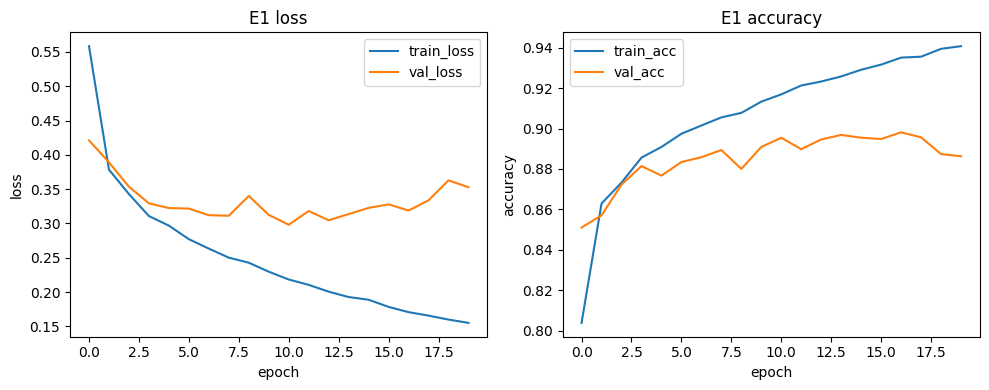

saved: artifacts/figures/curves_best.png


In [18]:
h = best_result["history"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(h["train_loss"], label="train_loss")
plt.plot(h["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"{best_result['experiment_id']} loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h["train_acc"], label="train_acc")
plt.plot(h["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"{best_result['experiment_id']} accuracy")
plt.legend()

plt.tight_layout()
curves_path = figures_dir / "curves_best.png"
plt.savefig(curves_path, dpi=140)
plt.show()

print("saved:", curves_path)


In [19]:
for r in sorted(results, key=lambda x: x["best_val_accuracy"], reverse=True):
    print(
        f"{r['experiment_id']}: best_val_acc={r['best_val_accuracy']:.4f}, "
        f"best_val_loss={r['best_val_loss']:.4f}, epochs={r['epochs_trained']}"
    )


E1: best_val_acc=0.8981, best_val_loss=0.3189, epochs=20
E0: best_val_acc=0.8950, best_val_loss=0.3016, epochs=20
E3: best_val_acc=0.8939, best_val_loss=0.3986, epochs=20
E2: best_val_acc=0.8935, best_val_loss=0.3066, epochs=20
E4: best_val_acc=0.8912, best_val_loss=0.3148, epochs=10
